# SVM Kernels Indepth Intution And Practical Expiation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.image as mpimg

In [2]:
x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
y = np.hstack([y, -y])
x = np.hstack([x, -x])

In [3]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1])

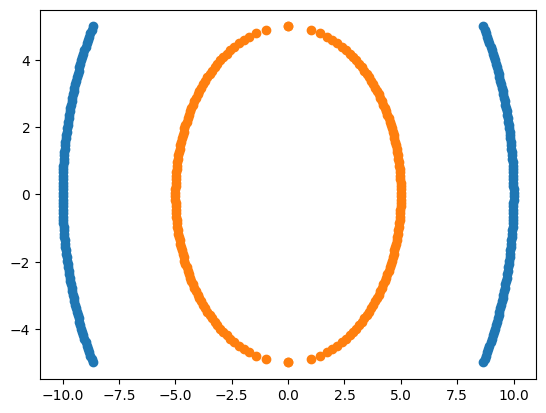

In [4]:
plt.scatter(y,x)
plt.scatter(y1, x1)

In [5]:
df1 = pd.DataFrame(np.vstack([y, x]).T, columns=['X1', 'X2'])
df1['Y'] = 0
df2 = pd.DataFrame(np.vstack([y1, x1]).T, columns=['X1', 'X2'])
df2['Y'] = 1
df = pd.concat([df1, df2])
df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [6]:
## Dependent and Independent Features
X = df.iloc[:, :2]
y = df.Y

### Polynomial Kernel K(x, y) = (transpose(x).y + c)**d

In [7]:
df['X1_Squired'] = df['X1']**2
df['X2_Squired'] = df['X2']**2
df['X1*X2'] = (df['X1']*df['X2'])
df.head()

,X1,X2,Y,X1_Squired,X2_Squired,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [8]:
X = df[['X1', 'X2', 'X1_Squired', 'X2_Squired', 'X1*X2']]
y = df['Y']

In [9]:
y

0      0
1      0
2      0
3      0
4      0
      ..
195    1
196    1
197    1
198    1
199    1
Name: Y, Length: 400, dtype: int64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
X_train

,X1,X2,X1_Squired,X2_Squired,X1*X2
157,-9.971263,-0.757576,99.426079,0.573921,7.553987
109,-9.124936,4.090909,83.264463,16.735537,-37.329285
17,9.445795,-3.282828,89.223038,10.776962,-31.008922
147,-4.993619,0.252525,24.936231,0.063769,-1.261015
24,9.662581,-2.575758,93.365473,6.634527,-24.888466
...,...,...,...,...,...
71,9.761334,2.171717,95.283645,4.716355,21.198857
106,-8.982945,4.393939,80.693297,19.306703,-39.470515
70,4.551063,2.070707,20.712172,4.287828,9.423918
148,-4.997704,0.151515,24.977043,0.022957,-0.757228


In [12]:
# !pip install plotly

In [13]:
import plotly.express as px

fig = px.scatter_3d(df, x = 'X1', y='X2', z='X1*X2', color = 'Y')
fig.show()

So if we plot the x1, x2 and x1*x2 this is not separable 

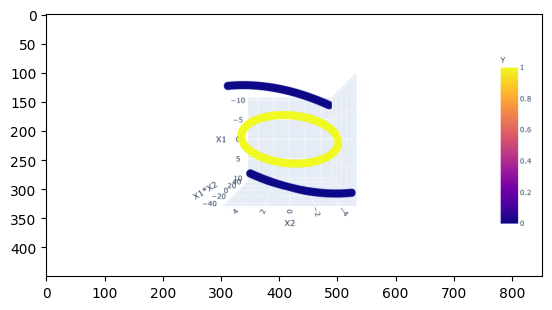

In [14]:
img = mpimg.imread('newplot.png')
plt.imshow(img)

In [15]:
fig = px.scatter_3d(df, x = 'X1_Squired', y='X2_Squired', z='X1*X2', color = 'Y')
fig.show()

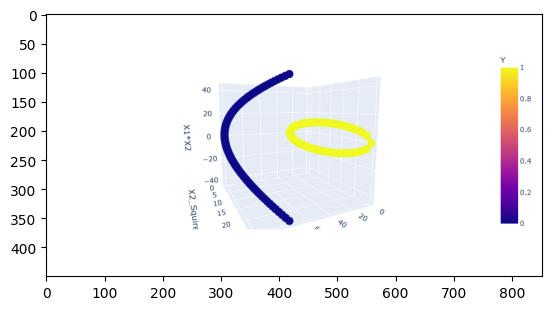

In [16]:
img = mpimg.imread('newplot1.png')
plt.imshow(img)

So if we plot the x1_Squired, x2_Squired and x1*x2 this is  separable after applying the Transformation

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test , y_pred))
print(confusion_matrix(y_test, y_pred))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        58

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

[[62  0]
 [ 0 58]]


In [18]:
classifier = SVC(kernel='poly')
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test , y_pred))
print(confusion_matrix(y_test, y_pred))

## If you apply the kernel='poly' then it is internally create the x1_squired and x2_squired for the separation

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        58

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

[[62  0]
 [ 0 58]]


In [19]:
classifier = SVC(kernel='rbf')
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test , y_pred))
print(confusion_matrix(y_test, y_pred))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        58

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

[[62  0]
 [ 0 58]]


In [20]:
classifier = SVC(kernel='sigmoid')
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test , y_pred))
print(confusion_matrix(y_test, y_pred))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        58

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

[[62  0]
 [ 0 58]]


## All are give the accuracy 1 because after applying the transformation the data is clearly separated to each other